# Co-fractionation evidence for protein complexes

**Question.** For a complex from Complex Portal, does the SEC co-fractionation data support it? We check three things:
1. **Co-elution:** do its subunits peak together more than random proteins do?
2. **Size:** does that peak sit where a particle of that mass can elute?
3. **Stoichiometry:** do subunit intensities follow the expected copy numbers?

**Inputs (nothing else is used):**
* the three co-fractionation tables (`highglu.tsv`, `nacl__1_.tsv`, `ypd.tsv`)
* the Complex Portal table for yeast
* the UniProt sequence table. This is the only source of protein masses, which are needed for the size and stoichiometry checks.
* two things from the lab, written into the notebook as plain parameters: the column's resolvable range (15 kDa to 1.5 MDa) and the CF-MS expert's list of obligate calibration anchors, mapped to yeast (section 5)

**What is different from the earlier version.**
* No fraction numbers are chosen by eye. The early "void" zone is derived from known complexes that sit inside your size window (section 4).
* Calibration uses only the expert's anchor list. A data-only alternative (Complex Portal homomers and dimers) was tried and does not work: those complexes are small and pile up at the zone edge, so the high-mass end is not identifiable.
* No loading correction between fractions, no 75%-co-peaking cut-off. Expected mass is that of the subunits that actually co-peak.
* Every remaining analysis choice is listed at the end (section 9), marked as biological or purely analytical.

In [1]:
from pathlib import Path
import itertools, re, warnings

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, mannwhitneyu, spearmanr, theilslopes

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#888780'

DATA = Path('.')                                   # folder with the input files
CF_FILES = {'highglu': 'highglu.tsv', 'nacl': 'nacl__1_.tsv', 'ypd': 'ypd.tsv'}
COMPLEX_FILE = 'Saccharomyces_cerevisiae_ComplexTab.tsv'
SEQUENCE_FILE = 'all_CF_YM_yeast_proteins_uniprot_mapped_sequences.csv'

WINDOW_KDA = (15, 1500)        # resolvable range of the column (from the lab)
N_NULL = 1000                  # random protein sets per complex size
rng = np.random.default_rng(0)

## 1. Load the data
**Masses and peptide counts** come from the sequences. Mass = sum of average residue masses + one water. The number of theoretical tryptic peptides (6-30 aa, cut after K/R but not before P) is used later to normalise intensities, similar to iBAQ.

In [2]:
RESIDUE_MASS = {'A': 71.0788, 'R': 156.1875, 'N': 114.1038, 'D': 115.0886, 'C': 103.1388, 'E': 129.1155,
                'Q': 128.1307, 'G': 57.0519, 'H': 137.1411, 'I': 113.1594, 'L': 113.1594, 'K': 128.1741,
                'M': 131.1926, 'F': 147.1766, 'P': 97.1167, 'S': 87.0782, 'T': 101.1051, 'W': 186.2132,
                'Y': 163.1760, 'V': 99.1326, 'U': 150.0388}

def mass_kda(seq):
    assert set(seq) <= set(RESIDUE_MASS), f'unexpected residue(s): {set(seq) - set(RESIDUE_MASS)}'
    return (sum(RESIDUE_MASS[aa] for aa in seq) + 18.015) / 1000

def n_tryptic_peptides(seq):
    peptides = re.sub(r'([KR])(?!P)', r'\1 ', seq).split()
    return max(1, sum(6 <= len(p) <= 30 for p in peptides))

sequences = (pl.read_csv(DATA / SEQUENCE_FILE)
               .drop_nulls('sequence')
               .unique('uniprot_id', keep='first', maintain_order=True)
               .with_columns(pl.col('sequence').str.replace_all('*', '', literal=True).str.strip_chars()))
MASS  = {acc: mass_kda(s) for acc, s in sequences.iter_rows()}
N_PEP = {acc: n_tryptic_peptides(s) for acc, s in sequences.iter_rows()}
print(f'{len(MASS)} proteins with a sequence')

2954 proteins with a sequence


**Elution profiles.** One row per protein (group), one column per fraction.
* Missing values mean "not detected" and are set to 0.
* Protein groups `A;B` are split into their accessions. If an accession appears in several rows, the row with the highest total intensity is kept.
* Light [1, 2, 1]/4 smoothing is used for peak finding. Intensity sums use the unsmoothed data.

In [3]:
class Profiles:
    '''Elution profiles of one condition.'''

    def __init__(self, path):
        table = (pl.read_csv(path, separator='\t', infer_schema_length=0)          # read as text: some columns are empty
                   .with_columns(pl.exclude('ID').cast(pl.Float64)).fill_null(0))
        assert table.columns[1:] == [str(i) for i in range(1, 61)], 'expected fraction columns 1..60'
        X = table.drop('ID').to_numpy()
        assert not np.isnan(X).any()
        best_row = {}
        for i, group in enumerate(table['ID']):
            for acc in group.strip('[]').split(';'):
                if acc not in best_row or X[i].sum() > X[best_row[acc]].sum():
                    best_row[acc] = i
        self.accs = list(best_row)
        self.row = {a: i for i, a in enumerate(self.accs)}
        self.raw = X[list(best_row.values())]
        self.smooth = np.apply_along_axis(lambda v: np.convolve(v, [1, 2, 1], 'same') / 4, 1, self.raw)
        self.mass = np.array([MASS.get(a, np.nan) for a in self.accs])

    def __contains__(self, acc):
        return acc in self.row

    def rows(self, accs, kind='smooth'):
        return getattr(self, kind)[[self.row[a] for a in accs]]

PROFILES = {cond: Profiles(DATA / f) for cond, f in CF_FILES.items()}
for cond, p in PROFILES.items():
    print(f'{cond:8s} {len(p.accs)} proteins, {np.isfinite(p.mass).sum()} with known mass')

highglu  3593 proteins, 2324 with known mass
nacl     3642 proteins, 2347 with known mass
ypd      2187 proteins, 1490 with known mass


**Complexes.** Parsed from the *Expanded participant list* (falling back to *Identifiers*).
* Complexes with a paralogue set `[P1,P2]` are dropped, because it is unclear which paralogue is in the complex.
* Complexes with an unknown copy number (0) for any protein are dropped.
* Non-protein participants (RNA, ligands) are ignored, so masses of such complexes are lower bounds. They are flagged.

In [4]:
PARTICIPANT = re.compile(r'(\[[^\]]+\]|[^|()]+)\((\d+)\)')
UNIPROT = re.compile(r'^[OPQ][0-9][A-Z0-9]{3}[0-9]|^[A-NR-Z][0-9]')

portal = pl.read_csv(DATA / COMPLEX_FILE, separator='\t', quote_char=None, infer_schema_length=0)
COMPLEXES = []
for ac, name, ids, expanded in portal.select('#Complex ac', 'Recommended name',
                                             'Identifiers (and stoichiometry) of molecules in complex',
                                             'Expanded participant list').iter_rows():
    ids, expanded = ids or '', expanded or '-'
    if '[' in ids or '[' in expanded:
        continue
    parts = PARTICIPANT.findall(expanded if expanded != '-' else ids)
    subunits = {acc.split('-')[0]: int(n) for acc, n in parts if UNIPROT.match(acc)}
    if subunits and all(n > 0 for n in subunits.values()):
        COMPLEXES.append(dict(ac=ac, name=name, subunits=subunits, has_non_protein=len(subunits) < len(parts)))
BY_AC = {c['ac']: c for c in COMPLEXES}

def expected_mass(subunits):
    '''Sum of copies x subunit mass (nan if any mass is unknown).'''
    return sum(n * MASS.get(acc, np.nan) for acc, n in subunits.items())

TARGETS = [c for c in COMPLEXES if len(c['subunits']) >= 3]
print(f'{len(portal)} complexes -> {len(COMPLEXES)} usable -> {len(TARGETS)} with >= 3 proteins, '
      f'{sum(c["has_non_protein"] for c in TARGETS)} of those also contain non-protein molecules')
assert len(TARGETS) > 0

634 complexes -> 298 usable -> 157 with >= 3 proteins, 0 of those also contain non-protein molecules


## 2. Co-elution score
For a set of proteins, the smoothed profiles are scaled to their maxima.
1. **Candidate peaks** are the peaks of the mean profile.
2. At each candidate, the **co-peaking subunits** are those with their own peak within +-2 fractions (about the width of a peak).
3. **score = (share of subunits co-peaking) x (mean pairwise Pearson r of the co-peaking subunits, within +-4 fractions)**. It runs from 0 to 1.

**Significance** comes from random protein sets of the same size drawn from the same condition, scored by the identical procedure. The p-value is the share of random sets with a score at least as high. Because random sets also see any pile-up of proteins in a region, the null automatically accounts for it. P-values within a condition are corrected with Benjamini-Hochberg (q).

In [ ]:
def scale_to_max(X):
    top = X.max(axis=1, keepdims=True)
    return X / np.where(top > 0, top, 1)

def peak_positions(profile, **kwargs):
    '''1-based fraction numbers of peaks (zero padding lets peaks at the edges count).'''
    return find_peaks(np.r_[0, profile, 0], **kwargs)[0]

def coelution_features(S, window=4, tolerance=2):
    P = scale_to_max(S)
    own_peaks = [peak_positions(p, height=0.1, prominence=0.05) for p in P]
    features = []
    for apex in peak_positions(P.mean(axis=0), prominence=0.03):
        members = [i for i, pk in enumerate(own_peaks) if np.any(np.abs(pk - apex) <= tolerance)]
        corr = 0.0
        if len(members) >= 2:
            r = np.corrcoef(P[members, max(0, apex - 1 - window):apex + window])
            corr = max(0.0, np.nan_to_num(np.nanmean(r[np.triu_indices(len(members), 1)])))
        features.append(dict(apex=int(apex), members=members, frac=len(members) / len(P), score=len(members) / len(P) * corr))
    return features

def random_sets(p, sizes, n_sets):
    '''Features of random protein sets. Each feature is (apex, score, summed mass of co-peaking proteins).'''
    pool = np.flatnonzero(np.isfinite(p.mass))
    null = {}
    for k in sizes:
        sets = []
        for _ in range(n_sets if k <= 12 else n_sets // 3):
            pick = rng.choice(pool, k, replace=False)
            sets.append([(f['apex'], f['score'], p.mass[pick][f['members']].sum()) for f in coelution_features(p.smooth[pick])])
        null[k] = sets
    return null

def best_after(features, first_fraction):
    '''Highest-scoring feature (tuple form) with apex >= first_fraction, or (nan, 0, nan) if there is none.'''
    kept = [f for f in features if f[0] >= first_fraction]
    return max(kept, key=lambda f: f[1]) if kept else (np.nan, 0.0, np.nan)

def benjamini_hochberg(p):
    p = np.asarray(p, float); q = np.empty(len(p)); running = 1.0
    for rank, i in reversed(list(enumerate(np.argsort(p), start=1))):
        running = min(running, p[i] * len(p) / rank)
        q[i] = running
    return q

In [6]:
BENCHMARK = [c for c in COMPLEXES if len(c['subunits']) >= 2]        # >= 2 proteins (heterodimers help the stoichiometry part)
NULLS = {}
for cond, p in PROFILES.items():
    largest = max(len([a for a in c['subunits'] if a in p]) for c in BENCHMARK)
    sizes = list(range(2, largest + 1))                     # every size, so any anchor or complex finds its null
    NULLS[cond] = random_sets(p, sizes, N_NULL)
    print(cond, f'null built: {sum(len(v) for v in NULLS[cond].values())} random sets, sizes {sizes[0]}-{sizes[-1]}')

highglu null built: 18992 random sets, sizes 2-36


nacl null built: 19325 random sets, sizes 2-37


ypd null built: 17660 random sets, sizes 2-32


In [7]:
_null_best_cache = {}
def null_best_scores(cond, k, first_fraction):
    '''Best score of each random set of size k, ignoring features before first_fraction.'''
    key = (cond, k, first_fraction)
    if key not in _null_best_cache:
        _null_best_cache[key] = np.array([best_after(s, first_fraction)[1] for s in NULLS[cond][k]])
    return _null_best_cache[key]

def score_complexes(cond, first_fraction):
    '''Best co-elution feature (apex >= first_fraction) for every complex with >= 2 detected proteins.'''
    p = PROFILES[cond]
    rows = []
    for c in BENCHMARK:
        detected = [a for a in c['subunits'] if a in p]
        if len(detected) < 2:
            continue
        features = [f for f in coelution_features(p.rows(detected)) if f['apex'] >= first_fraction]
        null_best = null_best_scores(cond, len(detected), first_fraction)
        row = dict(ac=c['ac'], name=c['name'], condition=cond, n_subunits=len(c['subunits']), n_detected=len(detected),
                   mass_complex=expected_mass(c['subunits']), apex=None, score=0.0, p=1.0, members=[], mass_members=np.nan)
        if features:                                   # no peak at all -> nothing to test, kept with score 0 and p = 1
            f = max(features, key=lambda f: f['score'])
            members = [detected[i] for i in f['members']]
            row.update(apex=f['apex'], score=f['score'], members=members,
                       p=(1 + (null_best >= f['score']).sum()) / (1 + len(null_best)),
                       mass_members=expected_mass({a: c['subunits'][a] for a in members}))
        rows.append(row)
    table = pl.DataFrame(rows, infer_schema_length=None)
    return table.with_columns(q=pl.Series(benjamini_hochberg(table['p'].to_numpy())), n_members=pl.col('members').list.len())

full_range = {cond: score_complexes(cond, first_fraction=1) for cond in PROFILES}        # nothing excluded yet
print({c: int((t['q'] < 0.05).sum()) for c, t in full_range.items()}, '<- complexes with q < 0.05 anywhere in the profile')

{'highglu': 100, 'nacl': 131, 'ypd': 60} <- complexes with q < 0.05 anywhere in the profile


## 3. The early zone, defined from known complexes
Your rule: *a complex whose mass is inside the column's window (15 kDa - 1.5 MDa) and that co-elutes convincingly cannot be in the void.* So the void can only end before the earliest fraction where such a complex peaks.

To find how early something that is still inside the window can elute, we use the heaviest complexes in the window: expected mass (of the co-peaking subunits) between half the upper limit and the upper limit. Half is used because the mass-position relationship below is only good to about 2-fold.
**The zone is every fraction before the earliest convincing (q < 0.05) peak of such a complex.**

In [8]:
lo_kda, hi_kda = WINDOW_KDA
FIRST_FRACTION = {}
for cond, table in full_range.items():
    convincing = table.filter(pl.col('q') < 0.05, pl.col('apex').is_not_null())
    heavy = convincing.filter(pl.col('mass_members').is_between(hi_kda / 2, hi_kda)).sort('apex')
    in_window = convincing.filter(pl.col('mass_members').is_between(lo_kda, hi_kda))
    assert heavy.height >= 3, f'{cond}: fewer than 3 convincing complexes near the upper window limit'
    FIRST_FRACTION[cond] = int(heavy['apex'].min())
    print(f'{cond}: zone ends before fraction {FIRST_FRACTION[cond]} (earliest of {heavy.height} heavy in-window complexes; '
          f'earliest of all {in_window.height} in-window complexes: {in_window["apex"].min()})')
    print('   earliest heavy complexes:', [(r['name'][:28], round(r['mass_members']), r['apex']) for r in heavy.head(4).iter_rows(named=True)])

highglu: zone ends before fraction 12 (earliest of 10 heavy in-window complexes; earliest of all 98 in-window complexes: 9)
   earliest heavy complexes: [('Vacuolar proton translocatin', 999, 12), ('Vacuolar proton translocatin', 993, 12), ('HIR histone chaperone comple', 1236, 15), ('INO80 chromatin remodeling c', 1234, 15)]
nacl: zone ends before fraction 11 (earliest of 9 heavy in-window complexes; earliest of all 127 in-window complexes: 9)
   earliest heavy complexes: [('Vacuolar proton translocatin', 946, 11), ('Vacuolar proton translocatin', 940, 11), ('TRAPP II complex', 981, 12), ('SEA complex', 1015, 12)]
ypd: zone ends before fraction 19 (earliest of 4 heavy in-window complexes; earliest of all 58 in-window complexes: 12)
   earliest heavy complexes: [('54S mitochondrial large ribo', 868, 19), ('26S proteasome complex', 757, 22), ('6-phosphofructokinase comple', 850, 31), ('Chaperonin-containing T-comp', 955, 35)]


**Check: does position still tell us the mass in those early fractions?**
Below, all convincing complexes are plotted by where they peak and by their expected mass. If elution position reflects size, the points should fall along a downward trend (heavier = earlier). The table gives the rank correlation between peak fraction and log mass, using only complexes that peak at or after a given fraction.

convincing  -> best co-elution score beats what random protein sets of the same size give, with the false discovery rate controlled at 5% across all complexes in that condition.

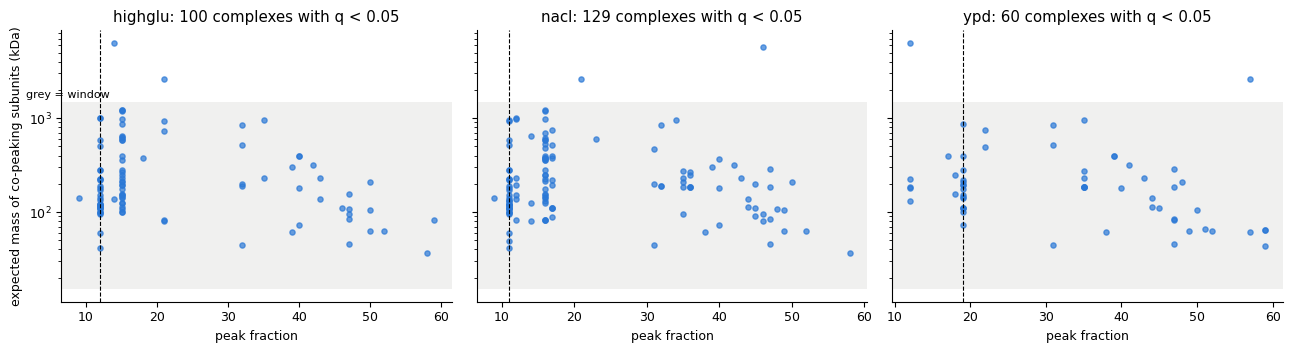

peaks_from_fraction,rho_highglu,rho_nacl,rho_ypd,p_highglu,p_nacl,p_ypd,n_highglu,n_nacl,n_ypd
i64,f64,f64,f64,f64,f64,f64,i64,i64,i64
9,-0.05,-0.01,-0.34,0.608,0.939,0.008,100,129,60
12,-0.06,-0.31,-0.34,0.561,0.003,0.008,99,94,60
15,-0.4,-0.39,-0.35,0.001,0.0,0.01,66,84,55
18,-0.51,-0.47,-0.33,0.002,0.001,0.016,34,44,54
21,-0.49,-0.47,-0.54,0.004,0.001,0.001,33,44,36
24,-0.52,-0.41,-0.47,0.004,0.007,0.005,28,42,34
27,-0.52,-0.41,-0.47,0.004,0.007,0.005,28,42,34
30,-0.52,-0.41,-0.47,0.004,0.007,0.005,28,42,34


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (cond, table) in zip(axes, full_range.items()):
    ok = table.filter(pl.col('q') < 0.05, pl.col('mass_members').is_finite())
    ax.axhspan(lo_kda, hi_kda, color=GREY, alpha=0.12, lw=0)
    ax.scatter(ok['apex'], ok['mass_members'], s=14, c=BLUE, alpha=0.7)
    ax.axvline(FIRST_FRACTION[cond], color='k', ls='--', lw=0.8)
    ax.set(yscale='log', xlabel='peak fraction', title=f'{cond}: {ok.height} complexes with q < 0.05')
axes[0].set_ylabel('expected mass of co-peaking subunits (kDa)')
axes[0].text(1.5, hi_kda * 1.1, 'grey = window', fontsize=8)
plt.tight_layout(); plt.show()

rows = []
for cond, table in full_range.items():
    ok = table.filter(pl.col('q') < 0.05, pl.col('mass_members').is_finite())
    for f in range(9, 31, 3):
        t = ok.filter(pl.col('apex') >= f)
        if t.height < 8:
            continue
        rho, pv = spearmanr(t['apex'], np.log10(t['mass_members']))
        rows.append(dict(condition=cond, peaks_from_fraction=f, n=t.height, rho=round(rho, 2), p=round(pv, 3)))
pl.DataFrame(rows).pivot(on='condition', index='peaks_from_fraction', values=['rho', 'p', 'n'])

**Reading it.**
* By your rule the zone is short: complexes of 1-1.5 MDa (V-ATPase, INO80, TRAPP II, HIR ...) peak as early as fractions 9-11, so nothing inside the window is excluded beyond that.
* But in fractions ~10-19 the peak position does not follow mass. Complexes of ~100 kDa and ~1 MDa peak at the same place (the correlation is absent or weak there and appears from roughly fraction 20 on).
* So these early fractions are *not* void by size, and *not* size-resolved either. They contain material whose elution is decided by something other than mass (for example membrane or chromatin attachment, or aggregation). That is a hypothesis; the data only show the lack of a size relationship.
* The size check therefore must not trust a mass derived from a peak in this region. Section 6 handles this by reporting such complexes as "elute earlier than their mass predicts" instead of scoring them.

From here on, scoring is repeated with the zone excluded.

In [10]:
scores = {cond: score_complexes(cond, FIRST_FRACTION[cond]) for cond in PROFILES}

## 4. Figure 1: do subunits co-elute?

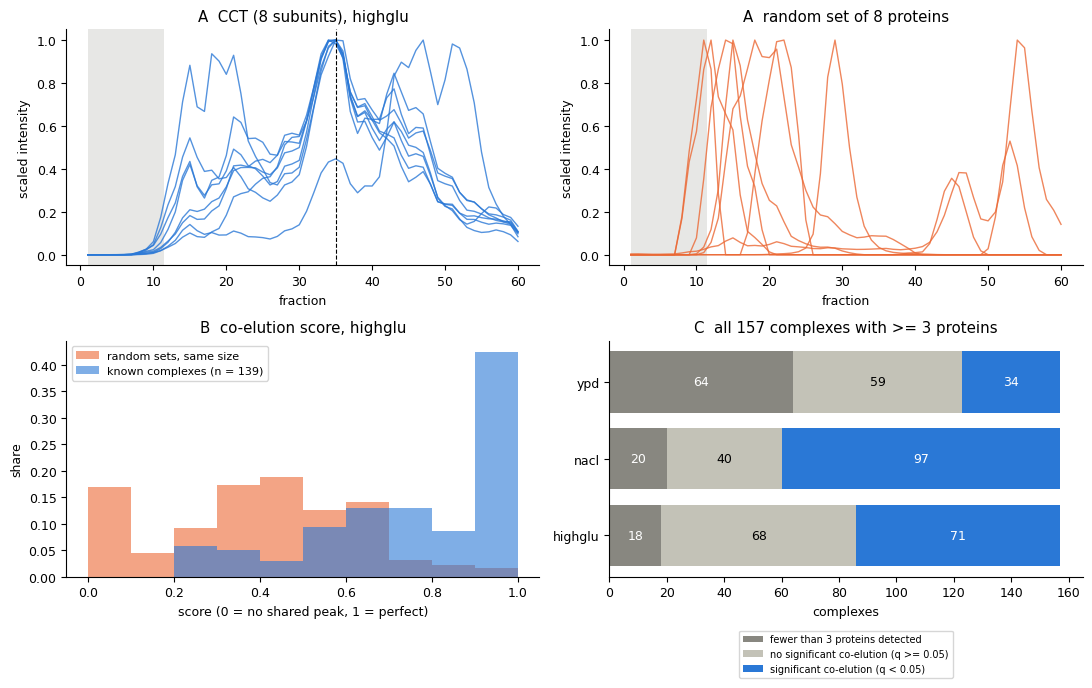

In [11]:
SHOW = 'highglu'
p = PROFILES[SHOW]
cct = next(c for c in TARGETS if c['name'].startswith('Chaperonin-containing T'))
cct_detected = [a for a in cct['subunits'] if a in p]
cct_apex = scores[SHOW].filter(pl.col('ac') == cct['ac'])['apex'][0]
assert cct_apex is not None, 'CCT has no peak after the early zone'
random_pick = rng.choice(np.flatnonzero(np.isfinite(p.mass)), len(cct_detected), replace=False)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, profiles_, colour, title in [(axes[0, 0], scale_to_max(p.rows(cct_detected)), BLUE, f'A  CCT ({len(cct_detected)} subunits), {SHOW}'),
                                     (axes[0, 1], scale_to_max(p.smooth[random_pick]), ORANGE, f'A  random set of {len(cct_detected)} proteins')]:
    for v in profiles_:
        ax.plot(range(1, 61), v, color=colour, lw=1, alpha=0.8)
    ax.axvspan(1, FIRST_FRACTION[SHOW] - 0.5, color=GREY, alpha=0.2, lw=0)
    ax.set(title=title, xlabel='fraction', ylabel='scaled intensity')
axes[0, 0].axvline(cct_apex, color='k', ls='--', lw=0.8)

# B: observed scores against random sets of the same size
t = scores[SHOW].filter(pl.col('n_detected') >= 3)
null_scores = np.concatenate([rng.choice(null_best_scores(SHOW, k, FIRST_FRACTION[SHOW]), 50) for k in t['n_detected']])
bins = np.linspace(0, 1, 11)
axes[1, 0].hist(null_scores, bins, weights=np.full(len(null_scores), 1 / len(null_scores)), color=ORANGE, alpha=0.6, label='random sets, same size')
axes[1, 0].hist(t['score'], bins, weights=np.full(t.height, 1 / t.height), color=BLUE, alpha=0.6, label=f'known complexes (n = {t.height})')
axes[1, 0].set(title=f'B  co-elution score, {SHOW}', xlabel='score (0 = no shared peak, 1 = perfect)', ylabel='share')
axes[1, 0].legend(fontsize=8)

# C: what happens to every complex with >= 3 proteins
labels = ['fewer than 3 proteins detected', 'no significant co-elution (q >= 0.05)', 'significant co-elution (q < 0.05)']
counts = {}
for cond, table in scores.items():
    scored = table.filter(pl.col('n_subunits') >= 3, pl.col('n_detected') >= 3)
    counts[cond] = [len(TARGETS) - scored.height, int((scored['q'] >= 0.05).sum()), int((scored['q'] < 0.05).sum())]
left = np.zeros(len(counts))
for i, (label, colour) in enumerate(zip(labels, [GREY, '#c3c2b7', BLUE])):
    vals = np.array([counts[c][i] for c in counts])
    axes[1, 1].barh(list(counts), vals, left=left, color=colour, label=label)
    for y, (v, l) in enumerate(zip(vals, left)):
        axes[1, 1].text(l + v / 2, y, v, ha='center', va='center', color='white' if i != 1 else 'k')
    left += vals
axes[1, 1].set(title=f'C  all {len(TARGETS)} complexes with >= 3 proteins', xlabel='complexes')
axes[1, 1].legend(fontsize=7, loc='lower center', bbox_to_anchor=(0.5, -0.45))
plt.tight_layout(); plt.show()

## 5. Fraction to mass: calibration from obligate anchors
The column's fraction numbers need a translation to mass, and no standards were spiked in. The CF-MS expert's list of obligate, stable complexes is used instead (human list mapped to yeast; paralogues noted). **This list is the one piece of outside knowledge the calibration depends on.**

How a peak is assigned to an anchor, with no hand-tuning:
* **Single protein:** the highest peak(s) after the early zone. An anchor with two states of the same protein (Pol30 trimer and monomer) takes the two highest peaks, the earlier one for the larger state.
* **Complex:** its best co-elution feature after the early zone, required to be significant (p < 0.05 against random sets of the same size). The anchor's mass is that of the subunits co-peaking in the feature.

Anchors that fail are listed and left out. The fit is a robust Theil-Sen line of log10 mass against fraction, one per condition.

In [12]:
def same_copies(accessions, copies):
    return dict.fromkeys(accessions, copies)

EXPERT_ANCHORS = {                       # name: {yeast UniProt accession: copies}
    'Sod1 dimer': {'P00445': 2},
    'Tpi1 dimer': {'P00942': 2},
    'Eno1 dimer': {'P00924': 2},         # Eno1 / Eno2 are ~95% identical; both are used
    'Eno2 dimer': {'P00925': 2},
    'Tdh3 tetramer': {'P00359': 4},      # Tdh1 / Tdh2 / Tdh3 are paralogues; only Tdh3 is used
    'Gln1 decamer': {'P32288': 10},
    'Pol30 trimer': {'P15873': 3},       # PCNA: two peaks, trimer and monomer
    'Pol30 monomer': {'P15873': 1},
    'Prefoldin': same_copies(['P40005', 'P46988', 'P48363', 'P52553', 'P53900', 'Q04493'], 1),
    'Arp2/3': same_copies(['P32381', 'P33204', 'P38328', 'P40518', 'P47117', 'P53731', 'Q05933'], 1),
    'COPI coatomer': same_copies(['P32074', 'P40509', 'P41810', 'P41811', 'P43621', 'P53600', 'P53622'], 1),
    'MCM2-7': same_copies(['P24279', 'P29469', 'P29496', 'P30665', 'P38132', 'P53091'], 1),
    '20S proteasome': same_copies(['P22141', 'P30656', 'P38624', 'P30657', 'P40302', 'P40303', 'P23724',
                                   'P23639', 'P23638', 'P21242', 'P25043', 'P32379', 'P25451', 'P21243'], 2),
    'CCT / TRiC': same_copies(['P12612', 'P39076', 'P39077', 'P39078', 'P39079', 'P40413', 'P42943', 'P47079'], 2),
}

def find_anchors(cond):
    p, first = PROFILES[cond], FIRST_FRACTION[cond]
    by_protein = {}                                                  # anchors that are states of the same protein(s)
    for name, subunits in EXPERT_ANCHORS.items():
        by_protein.setdefault(tuple(sorted(subunits)), []).append((expected_mass(subunits), name, subunits))
    rows, rejected = [], []
    for accs, states in by_protein.items():
        states = sorted(states, reverse=True)                       # larger state first
        detected = [a for a in accs if a in p]
        if len(detected) < len(accs) / 2:
            rejected += [(name, 'fewer than half of the subunits detected') for _, name, _ in states]
            continue
        if len(accs) == 1:
            peaks = peak_positions(scale_to_max(p.rows(accs))[0], height=0.1, prominence=0.05)
            peaks = [x for x in peaks if x >= first]
            top = sorted(sorted(peaks, key=lambda x: -p.smooth[p.row[accs[0]], x - 1])[:len(states)])
            if len(top) < len(states):
                rejected += [(name, f'only {len(top)} peak(s) after the early zone') for _, name, _ in states]
                continue
            rows += [dict(condition=cond, name=name, accs=','.join(accs), fraction=int(x), mass=mass) for (mass, name, _), x in zip(states, top)]
        else:
            feature = max([f for f in coelution_features(p.rows(detected)) if f['apex'] >= first], key=lambda f: f['score'], default=None)
            if feature is None:
                rejected.append((states[0][1], 'no peak after the early zone'))
                continue
            p_value = (1 + (null_best_scores(cond, len(detected), first) >= feature['score']).sum()) / (1 + len(NULLS[cond][len(detected)]))
            if p_value >= 0.05:
                rejected.append((states[0][1], f'co-elution not significant (p = {p_value:.2f})'))
                continue
            members = {detected[i]: states[0][2][detected[i]] for i in feature['members']}
            rows.append(dict(condition=cond, name=states[0][1], accs=','.join(members), fraction=feature['apex'], mass=expected_mass(members)))
    print(f'{cond}: {len(rows)} anchor points; not used: {rejected or "none"}')
    return pl.DataFrame(rows)

ANCHORS = pl.concat([find_anchors(cond) for cond in PROFILES])
for cond in PROFILES:
    assert ANCHORS.filter(pl.col('condition') == cond).height >= 8, f'{cond}: too few anchors for a calibration'

def fit_calibration(anchors):
    slope, intercept, *_ = theilslopes(np.log10(anchors['mass']), anchors['fraction'])
    return lambda fraction: 10 ** (intercept + slope * np.asarray(fraction, float))

CALIBRATION = {cond: fit_calibration(ANCHORS.filter(pl.col('condition') == cond)) for cond in PROFILES}

def fraction_at(cond, mass_kda):
    '''Fraction where the calibration line reaches a given mass (mass falls with fraction number).'''
    grid = np.linspace(-20, 100, 1201)
    return float(np.interp(np.log10(mass_kda), np.log10(CALIBRATION[cond](grid))[::-1], grid[::-1]))

def apparent_mass(cond, apex, anchors=None):
    '''Mass read from the calibration, limited to the window (outside it the column gives no size information).'''
    calib = CALIBRATION[cond] if anchors is None else fit_calibration(anchors)
    return np.clip(calib(apex), lo_kda, hi_kda)

highglu: 13 anchor points; not used: [('MCM2-7', 'co-elution not significant (p = 0.61)')]
nacl: 14 anchor points; not used: none
ypd: 14 anchor points; not used: none


highglu: anchors span fractions 31-54 (29-955 kDa); the line reaches 1.5 MDa at fraction 28 (extrapolated above the heaviest anchor) and 15 kDa at 60
nacl: anchors span fractions 23-53 (29-955 kDa); the line reaches 1.5 MDa at fraction 27 (extrapolated above the heaviest anchor) and 15 kDa at 62
ypd: anchors span fractions 22-57 (29-955 kDa); the line reaches 1.5 MDa at fraction 25 (extrapolated above the heaviest anchor) and 15 kDa at 65


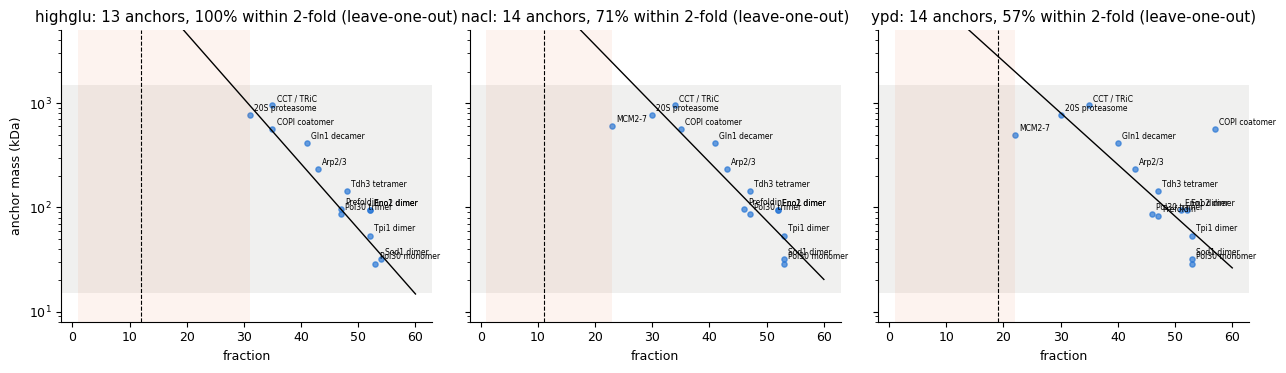

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
fractions = np.arange(1, 61)
for ax, cond in zip(axes, PROFILES):
    a = ANCHORS.filter(pl.col('condition') == cond)
    loo = []
    for i in range(a.height):
        rest = a.filter(pl.int_range(pl.len()) != i)
        loo.append(np.log2(fit_calibration(rest)(a['fraction'][i]) / a['mass'][i]))
    loo = np.array(loo)
    ax.axhspan(lo_kda, hi_kda, color=GREY, alpha=0.12, lw=0)
    ax.scatter(a['fraction'], a['mass'], s=14, c=BLUE, alpha=0.7)
    for r in a.iter_rows(named=True):
        ax.annotate(r['name'], (r['fraction'], r['mass']), fontsize=5.5, xytext=(3, 3), textcoords='offset points')
    ax.plot(fractions, CALIBRATION[cond](fractions), 'k', lw=1)
    ax.axvspan(1, a['fraction'].min(), color=ORANGE, alpha=0.08, lw=0)
    ax.axvline(FIRST_FRACTION[cond], color='k', ls='--', lw=0.8)
    ax.set(yscale='log', ylim=(8, 5000), xlabel='fraction',
           title=f'{cond}: {a.height} anchors, {np.mean(np.abs(loo) <= 1):.0%} within 2-fold (leave-one-out)')
    print(f'{cond}: anchors span fractions {a["fraction"].min()}-{a["fraction"].max()} ({a["mass"].min():.0f}-{a["mass"].max():.0f} kDa); the line reaches 1.5 MDa at fraction {fraction_at(cond, hi_kda):.0f} (extrapolated above the heaviest anchor) and 15 kDa at {fraction_at(cond, lo_kda):.0f}')
axes[0].set_ylabel('anchor mass (kDa)')
plt.tight_layout(); plt.show()

## 6. Figure 3: does the size check help?
For every complex with significant co-elution we compare where it peaks with where a particle of its mass should peak:
**ratio = log2(apparent mass / expected mass of the co-peaking subunits)**, with apparent mass limited to the window.

The check is **one-sided** because of a physical fact: a stable complex cannot be smaller than the sum of its parts. If it elutes as if it were much *smaller*, the subunits are not together as that assembly. If it elutes as if *larger*, many harmless explanations exist (elongated shape, RNA, extra partners, membrane), so this is only reported, not penalised.

Complexes that share a protein with an anchor are calibrated without that anchor. Random protein sets that also pass the co-elution test (best score at or above the 95th percentile for their size) serve as decoys.

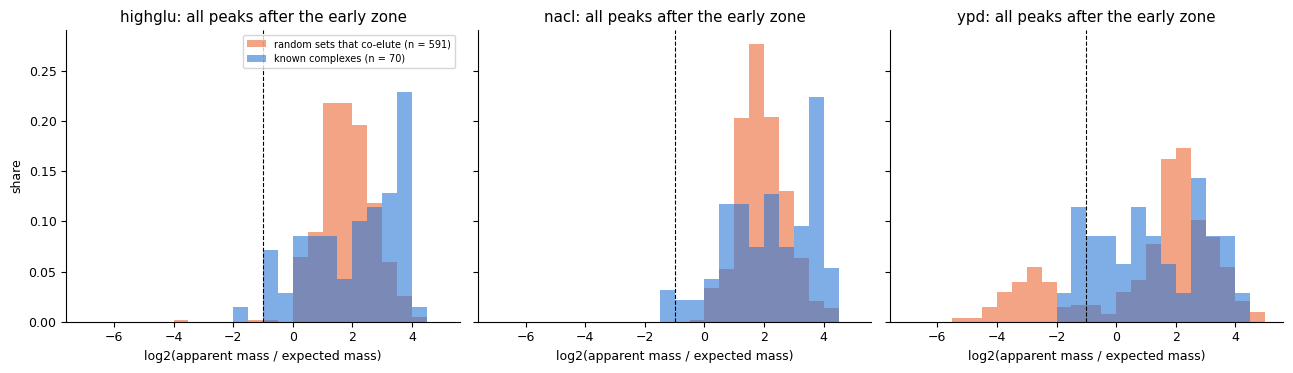

condition,complexes,decoys,complexes_below_half,decoys_below_half,auc_one_sided,auc_two_sided,complexes_at_window_top,decoys_at_window_top
str,i64,i64,f64,f64,f64,f64,f64,f64
"""highglu""",70,591,0.01,0.0,0.45,0.4,0.8,0.99
"""nacl""",94,568,0.03,0.0,0.46,0.43,0.76,1.0
"""ypd""",35,532,0.14,0.22,0.5,0.65,0.49,0.75


In [14]:
def complex_ratios(cond, table):
    t = table.filter(pl.col('q') < 0.05, pl.col('n_subunits') >= 3, pl.col('mass_members').is_between(lo_kda, hi_kda))
    anchors = ANCHORS.filter(pl.col('condition') == cond)
    apparent = []
    for r in t.iter_rows(named=True):
        shares_protein = anchors['accs'].map_elements(lambda s: bool(set(s.split(',')) & set(BY_AC[r['ac']]['subunits'])), return_dtype=pl.Boolean)
        apparent.append(apparent_mass(cond, r['apex'], anchors.filter(~shares_protein)))
    apparent = np.array(apparent)
    return np.log2(apparent / t['mass_members'].to_numpy()), apparent, t

def decoy_ratios(cond, sizes, first_fraction):
    ratios, apparent = [], []
    for k in sizes:
        threshold = np.quantile(null_best_scores(cond, k, first_fraction), 0.95)
        for apex, score, mass in (best_after(s, first_fraction) for s in NULLS[cond][k]):
            if score >= threshold and score > 0 and lo_kda <= mass <= hi_kda:
                apparent.append(apparent_mass(cond, apex))
                ratios.append(np.log2(apparent[-1] / mass))
    return np.array(ratios), np.array(apparent)

auc = lambda pos, neg: mannwhitneyu(pos, neg).statistic / (len(pos) * len(neg))

def size_check(tables, first_fraction, label):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
    summary = []
    for ax, cond in zip(axes, PROFILES):
        real, apparent, t = complex_ratios(cond, tables[cond])
        decoy, decoy_apparent = decoy_ratios(cond, sorted(set(t['n_detected'])), first_fraction[cond])
        summary.append(dict(condition=cond, complexes=len(real), decoys=len(decoy), complexes_below_half=np.mean(real < -1),
                            decoys_below_half=np.mean(decoy < -1), auc_one_sided=auc(np.minimum(real, 0), np.minimum(decoy, 0)),
                            auc_two_sided=auc(-np.abs(real), -np.abs(decoy)), complexes_at_window_top=np.mean(np.isclose(apparent, hi_kda)),
                            decoys_at_window_top=np.mean(np.isclose(decoy_apparent, hi_kda))))
        bins = np.arange(-7, 5.1, 0.5)
        ax.hist(decoy, bins, weights=np.full(len(decoy), 1 / len(decoy)), color=ORANGE, alpha=0.6, label=f'random sets that co-elute (n = {len(decoy)})')
        ax.hist(real, bins, weights=np.full(len(real), 1 / len(real)), color=BLUE, alpha=0.6, label=f'known complexes (n = {len(real)})')
        ax.axvline(-1, color='k', ls='--', lw=0.8)
        ax.set(title=f'{cond}: {label}', xlabel='log2(apparent mass / expected mass)')
    axes[0].set_ylabel('share'); axes[0].legend(fontsize=7)
    plt.tight_layout(); plt.show()
    return pl.DataFrame(summary).with_columns(pl.col(pl.Float64).round(2))

# (a) every peak after the early zone defined in section 3
size_check(scores, FIRST_FRACTION, 'all peaks after the early zone')

`*_at_window_top` is the share whose apparent mass hit the upper limit of the window, i.e. peaks earlier than the calibration's 1.5 MDa position (the line is extrapolated above the heaviest anchor). For these the ratio is not a measurement, only "earlier than the column can size". If real complexes and random co-eluting sets sit there equally often, the early fractions cannot be separated by size.

**(b) Inside the calibrated range only.** Both the complexes and the random sets are re-scored using only peaks at or after the fraction where the calibration reaches 1.5 MDa, so every ratio is a real reading.

calibrated range starts at fraction {'highglu': 28, 'nacl': 27, 'ypd': 25}


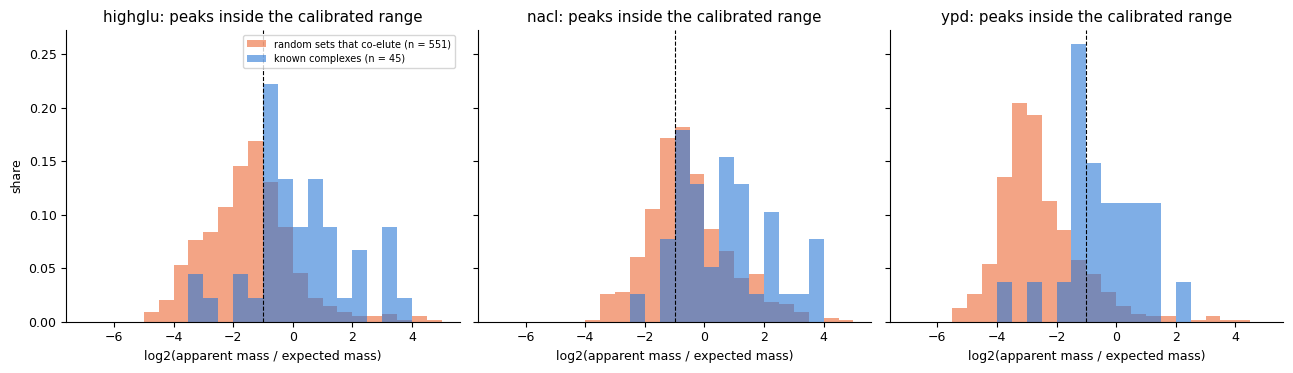

condition,complexes,decoys,complexes_below_half,decoys_below_half,auc_one_sided,auc_two_sided,complexes_at_window_top,decoys_at_window_top
str,i64,i64,f64,f64,f64,f64,f64,f64
"""highglu""",45,551,0.13,0.66,0.8,0.64,0.0,0.0
"""nacl""",39,543,0.1,0.39,0.7,0.49,0.0,0.0
"""ypd""",27,534,0.37,0.88,0.88,0.86,0.0,0.0


In [15]:
CALIBRATED_START = {cond: int(np.ceil(fraction_at(cond, hi_kda))) for cond in PROFILES}
calibrated_scores = {cond: score_complexes(cond, CALIBRATED_START[cond]) for cond in PROFILES}
print('calibrated range starts at fraction', CALIBRATED_START)
size_check(calibrated_scores, CALIBRATED_START, 'peaks inside the calibrated range')

## 7. Figure 4: stoichiometry from intensities
For complexes with significant co-elution, each co-peaking subunit's intensity is summed over the peak (apex +- 2 fractions, unsmoothed). Three versions are compared:
* raw intensity
* intensity / protein mass (larger proteins give more signal)
* intensity / number of theoretical tryptic peptides (iBAQ-like). This is only equivalent to iBAQ if the table holds summed peptide intensities; **we do not know that**.

**Benchmark:** all pairs of co-peaking subunits within a complex.
* *Unequal pairs* (different copy numbers): how often does the higher-copy subunit give more signal?
* *Equal pairs*: how far apart are subunits that should be 1:1 (noise)?

Complexes that share most of their subunits (PKA variants, V-ATPase, ...) are not independent, so they are grouped into **families** (>= half of the smaller complex's subunits shared), and confidence intervals come from resampling families.

In [16]:
def subunit_intensities():
    rows, dropped = [], set()
    for cond, table in scores.items():
        p = PROFILES[cond]
        for r in table.filter(pl.col('q') < 0.05, pl.col('n_members') >= 2).iter_rows(named=True):
            if any(acc not in MASS for acc in r['members']):          # mass and peptide count need a sequence
                dropped.add(r['name'])
                continue
            peak = slice(max(0, r['apex'] - 3), r['apex'] + 2)
            for acc in r['members']:
                intensity = p.raw[p.row[acc], peak].sum()
                if intensity > 0:
                    rows.append(dict(condition=cond, ac=r['ac'], acc=acc, copies=BY_AC[r['ac']]['subunits'][acc],
                                     raw=intensity, per_mass=intensity / MASS[acc], per_peptide=intensity / N_PEP[acc]))
    print(f'left out of the stoichiometry analysis (a subunit has no sequence): {sorted(dropped) or "none"}')
    return pl.DataFrame(rows)

def families(acs):
    parent = {a: a for a in acs}
    def root(a):
        while parent[a] != a:
            a = parent[a]
        return a
    for a, b in itertools.combinations(acs, 2):
        sa, sb = set(BY_AC[a]['subunits']), set(BY_AC[b]['subunits'])
        if len(sa & sb) >= 0.5 * min(len(sa), len(sb)):
            parent[root(a)] = root(b)
    return {a: root(a) for a in acs}

intensities = subunit_intensities()
fam = families(sorted(intensities['ac'].unique()))
intensities = intensities.with_columns(family=pl.col('ac').replace_strict(fam))

def subunit_pairs(quantity):
    '''Every pair of subunits in a complex x condition; expected and observed log2 ratio, oriented so expected >= 0.'''
    rows = []
    for g in intensities.partition_by('ac', 'condition'):
        for (n1, q1), (n2, q2) in itertools.combinations(zip(g['copies'], g[quantity]), 2):
            expected, observed = np.log2(n1 / n2), np.log2(q1 / q2)
            if expected < 0:
                expected, observed = -expected, -observed
            rows.append((g['family'][0], expected, observed))
    return pl.DataFrame(rows, schema=['family', 'expected', 'observed'], orient='row')

def direction_correct(pairs):
    unequal = pairs.filter(pl.col('expected') > 0)['observed'].to_numpy()
    return np.mean(unequal > 0)

def family_bootstrap(pairs, n=500):
    by_family = {f[0]: g for f, g in pairs.group_by('family')}
    names = list(by_family)
    values = [direction_correct(pl.concat([by_family[f] for f in rng.choice(names, len(names))])) for _ in range(n)]
    return np.percentile(values, [2.5, 97.5])

results = []
for quantity in ['raw', 'per_mass', 'per_peptide']:
    pairs = subunit_pairs(quantity)
    equal = np.abs(pairs.filter(pl.col('expected') == 0)['observed'].to_numpy())
    lo, hi = family_bootstrap(pairs)
    results.append(dict(quantity=quantity, unequal_pairs=int((pairs['expected'] > 0).sum()),
                        unequal_families=pairs.filter(pl.col('expected') > 0)['family'].n_unique(),
                        direction_correct=direction_correct(pairs), ci_low=lo, ci_high=hi, equal_pairs=len(equal),
                        equal_pair_median_fold=2 ** np.median(equal)))
stoichiometry = pl.DataFrame(results).with_columns(pl.col(pl.Float64).round(2))
stoichiometry

left out of the stoichiometry analysis (a subunit has no sequence): ['Mitochondrial respiratory chain complex IV, COX5A variant', 'Mitochondrial respiratory chain complex IV, COX5B variant']


quantity,unequal_pairs,unequal_families,direction_correct,ci_low,ci_high,equal_pairs,equal_pair_median_fold
str,i64,i64,f64,f64,f64,i64,f64
"""raw""",462,18,0.83,0.68,0.89,4856,2.23
"""per_mass""",462,18,0.93,0.86,0.98,4856,1.74
"""per_peptide""",462,18,0.91,0.83,0.97,4856,1.68


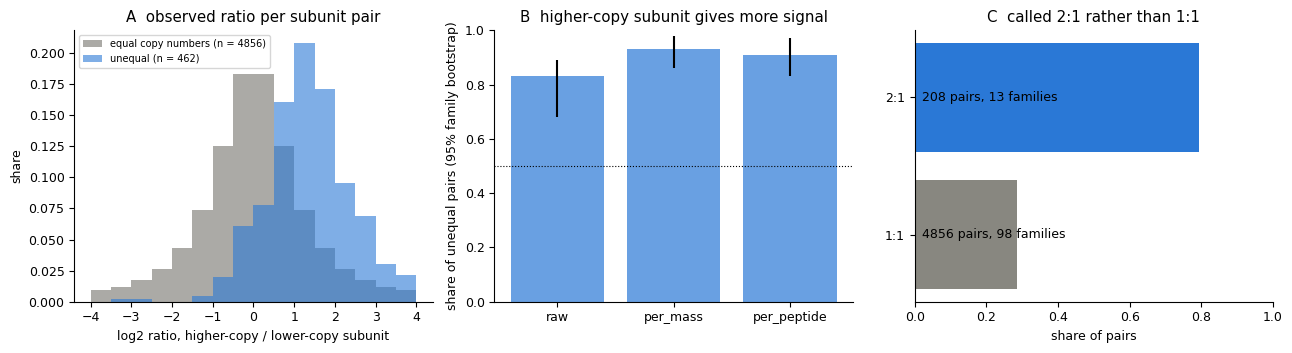

truth,pairs,families,called_2to1
str,u32,u32,f64
"""1:1""",4856,98,0.29
"""2:1""",208,13,0.79


In [17]:
pairs = subunit_pairs('per_peptide')
equal = pairs.filter(pl.col('expected') == 0)['observed'].to_numpy()
unequal = pairs.filter(pl.col('expected') > 0)['observed'].to_numpy()

# directed test: is this pair 2:1 rather than 1:1? Noise model = equal pairs from OTHER families, shifted by 1 under 2:1
two_to_one = pairs.filter((pl.col('expected') - 1).abs() < 1e-9)
tested = pl.concat([pairs.filter(pl.col('expected') == 0).with_columns(truth=pl.lit('1:1')),
                    two_to_one.with_columns(truth=pl.lit('2:1'))])
density = {}
calls = []
for family, observed, truth in tested.select('family', 'observed', 'truth').iter_rows():
    if family not in density:
        noise = pairs.filter((pl.col('expected') == 0) & (pl.col('family') != family))['observed'].to_numpy()
        density[family] = gaussian_kde(np.r_[noise, -noise])
    calls.append(density[family](observed - 1)[0] > density[family](observed)[0])
directed = tested.with_columns(called_2to1=pl.Series(calls)).group_by('truth').agg(
    pairs=pl.len(), families=pl.col('family').n_unique(), called_2to1=pl.col('called_2to1').mean())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
bins = np.arange(-4, 4.1, 0.5)
axes[0].hist(np.r_[equal, -equal], bins, weights=np.full(2 * len(equal), 1 / (2 * len(equal))), color=GREY, alpha=0.7, label=f'equal copy numbers (n = {len(equal)})')
axes[0].hist(unequal, bins, weights=np.full(len(unequal), 1 / len(unequal)), color=BLUE, alpha=0.6, label=f'unequal (n = {len(unequal)})')
axes[0].set(title='A  observed ratio per subunit pair', xlabel='log2 ratio, higher-copy / lower-copy subunit', ylabel='share'); axes[0].legend(fontsize=7)
r = stoichiometry
axes[1].bar(r['quantity'], r['direction_correct'], color=BLUE, alpha=0.7)
axes[1].errorbar(r['quantity'], r['direction_correct'], yerr=[r['direction_correct'] - r['ci_low'], r['ci_high'] - r['direction_correct']], fmt='none', color='k')
axes[1].axhline(0.5, color='k', ls=':', lw=0.8)
axes[1].set(title='B  higher-copy subunit gives more signal', ylabel='share of unequal pairs (95% family bootstrap)', ylim=(0, 1))
axes[2].barh(directed['truth'], directed['called_2to1'], color=[BLUE if t == '2:1' else GREY for t in directed['truth']])
for y, (n, f) in enumerate(zip(directed['pairs'], directed['families'])):
    axes[2].text(0.02, y, f'{n} pairs, {f} families', va='center')
axes[2].set(title='C  called 2:1 rather than 1:1', xlim=(0, 1), xlabel='share of pairs')
plt.tight_layout(); plt.show()
directed.with_columns(pl.col('called_2to1').round(2))

## 8. Numbers behind the figures

In [18]:
for cond, table in scores.items():
    t = table.filter(pl.col('n_subunits') >= 3, pl.col('n_detected') >= 3)
    print(f'{cond:8s} zone ends before fraction {FIRST_FRACTION[cond]:2d} | {t.height} of {len(TARGETS)} complexes testable | '
          f'{int((t["q"] < 0.05).sum())} with q < 0.05 | {int(((t["q"] < 0.05) & (t["apex"] < fraction_at(cond, hi_kda))).sum())} of those peak earlier than the calibration position of 1.5 MDa (fraction {fraction_at(cond, hi_kda):.0f})')

highglu  zone ends before fraction 12 | 139 of 157 complexes testable | 71 with q < 0.05 | 57 of those peak earlier than the calibration position of 1.5 MDa (fraction 28)
nacl     zone ends before fraction 11 | 137 of 157 complexes testable | 97 with q < 0.05 | 73 of those peak earlier than the calibration position of 1.5 MDa (fraction 27)
ypd      zone ends before fraction 19 | 93 of 157 complexes testable | 34 with q < 0.05 | 16 of those peak earlier than the calibration position of 1.5 MDa (fraction 25)


## 9. Choices in this analysis, and what supports each
| Choice | Basis |
|---|---|
| Column window 15 kDa - 1.5 MDa | given by the lab (biology / instrument) |
| Early zone = before the earliest convincing peak of a heavy in-window complex | follows from the window; sensitive to single complexes (the earliest ones are printed) |
| Missing intensity = 0 | "not detected"; could also be below detection while present |
| Expected mass = co-peaking subunits only | a complex can only be compared with what co-elutes |
| Paralogue sets and unknown copy numbers excluded | cannot assign which protein / how many |
| Non-protein molecules ignored | masses of RNA-containing complexes are lower bounds |
| Random sets as null, BH correction | statistical, no biological assumption |
| One-sided size check | physical: a stable complex cannot be lighter than its parts |
| Calibration anchors = the expert's list of obligate stable complexes, mapped to yeast | biological knowledge from the lab; the yeast mapping and the choice of paralogues are mine and listed in the code |
| Anchor peak = highest peak(s) after the early zone (single proteins) or the significant co-elution feature (complexes) | assumes the dominant pool is the assembled form |
| Straight line of log mass vs fraction | typical of SEC in its working range; not tested beyond the anchors |
| Peptide-count normalisation | MS principle (iBAQ); valid only if intensities are summed raw values |
| Co-peaking tolerance +-2, correlation window +-4, smoothing [1,2,1], peak height / prominence cut-offs | analytical choices (about one peak width); not derived from biology |
| Stoichiometry window apex +-2 fractions | analytical choice |
| Complex Portal stoichiometries taken as truth | some are simplified (for example the 26S proteasome has every subunit at 1) |

what to check
1. add ribosome, if eludes earlier problem, otherwise probably part of bigger assembly -and non log scale
2. add more complexes to calibration curve
3. which pairsare  dirving stoichiometry plot, if any? (cap at x amoun per perrs per prot that doesnt have stoi of just 1)
4. similar scores with cc profiler?
5. spread unequal pairs


look up
1) how do i get null distribution?
2)  how is peak fraction determined
3) what done with [airs that are 2:2]